# Pseudodata based measurement of the two-point energy correlator observable

This notebook implements the pseudodata based measurement of the two-point energy correlator observable (EEC) using the ATLAS Omnifold Z+jets measurement.
Running this measurement and observing good statistical agreement with the target truth pseudodata is a prerequisite for running the data measurement in `eec_data_results.ipynb`.

Note that running this notebook over all events in the samples is expensive!
Unless you have access to significant resources it is recommended to set `max_events` to an integer (default set to `None` in which case all events are used).
The histogramming of pairs of tracks is the computational bottleneck in this measurement.
It is accelerated using the `boost_histogram` python package and parallelized with dask.
See `eec_utils.py` for details.

In [1]:
%load_ext autoreload
%autoreload 2

## Preliminaries: load all data

In [2]:
import os
# Disable HDF5 file locking to avoid issues on the NERSC filesystems
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import pickle
import numpy as np
import pandas as pd
import dask.distributed as distributed

import eec_utils as eec
import visualize as vis

In [3]:
# ROOT file paths
staging_dir = "/global/cfs/cdirs/m3246/ZjetOmnifold/data/final_public_data"
tree_name = "OmniTree"

truth_mc_path = f"{staging_dir}/truth_mc_events.root"
truth_hv_path = f"{staging_dir}/truth_mc_hv_events.root"
truth_pseudodata_path = f"{staging_dir}/truth_pseudodata_events.root"

In [4]:
# Load event weights for pseudodata measurement
pseudodata_weights = pd.read_hdf(f"{staging_dir}/pseudodata_weights.h5")
pseudodata_hv_weights = pd.read_hdf(f"{staging_dir}/pseudodata_hv_weights.h5")
truth_pseudodata_weights = pd.read_hdf(f"{staging_dir}/truth_pseudodata_weights.h5")

## Prepare vectors of event weights

The nominal measurement an systematic uncertainties are build with vectors of event weights (see `basics.ipynb`).
All of these are loaded into memory here.

In [5]:
# Create dictionary containined all of the weight vectors needed for the pseudodata measurement
nominal_weights = pseudodata_weights["weights_nominal"].to_numpy()
n_init_weights = [name for name in pseudodata_weights.keys() if "weights_ensemble_" in name]
dbootstrap_weights = [name for name in pseudodata_weights.keys() if "weights_bootstrap_data_" in name]
mcbootstrap_train_weights = [name for name in pseudodata_weights.keys() if "weights_bootstrap_mc_" in name]
pd_weights = {
    "prior": pseudodata_weights["weights_prior"].to_numpy(),  # Also include weights for plotting the "prior" used in the measurement
    "nominal": nominal_weights,
    **{f"ensemble_{i}": pseudodata_weights[name].to_numpy() for i, name in enumerate(n_init_weights)},
    **{f"bootstrap_data_{i}": pseudodata_weights[name].to_numpy() for i, name in enumerate(dbootstrap_weights)},
    **{f"bootstrap_mc_{i}": pseudodata_weights[name].to_numpy() for i, name in enumerate(mcbootstrap_train_weights)},
    "trackEffMain": pseudodata_weights["weights_trackEffMain"].to_numpy(),
    "trackEffJet": pseudodata_weights["weights_trackEffJet"].to_numpy(),
    "trackFake": pseudodata_weights["weights_trackFake"].to_numpy(),
    "trackPtScale": pseudodata_weights["weights_trackPtScale"].to_numpy(),
    "muCalID": pseudodata_weights["weights_muCalID"].to_numpy(),
    "muCalMS": pseudodata_weights["weights_muCalMS"].to_numpy(),
    "muCalResBias": pseudodata_weights["weights_muCalResBias"].to_numpy(),
    "muCalScale": pseudodata_weights["weights_muCalScale"].to_numpy(),
    "muEffReco": pseudodata_weights["weights_muEffReco"].to_numpy(),
    "muEffIso": pseudodata_weights["weights_muEffIso"].to_numpy(),
    "muEffTrack": pseudodata_weights["weights_muEffTrack"].to_numpy(),
    "muEffTrig": pseudodata_weights["weights_muEffTrig"].to_numpy(),
    "pileup": pseudodata_weights["weights_pileup"].to_numpy(),
    "lumi": pseudodata_weights["weights_lumi"].to_numpy(),
    "theoryQCD": pseudodata_weights["weights_theoryQCD"].to_numpy(),
    "theoryPDF": pseudodata_weights["weights_theoryPDF"].to_numpy(),
    "theoryAlphaS": pseudodata_weights["weights_theoryAlphaS"].to_numpy(),
    "theoryPSsoft": pseudodata_weights["weights_theoryPSsoft"].to_numpy(),
    "theoryPSjet": pseudodata_weights["weights_theoryPSjet"].to_numpy(),
    "theoryPSscale": pseudodata_weights["weights_theoryPSscale"].to_numpy(),
    "theoryMPI": pseudodata_weights["weights_theoryMPI"].to_numpy(),
    "topBackground": pseudodata_weights["weights_topBackground"].to_numpy(),
    "nonstrongDiboson": pseudodata_weights["weights_nonstrongDiboson"].to_numpy(),
    "nonstrongEW": pseudodata_weights["weights_nonstrongEW"].to_numpy(),
    "dd": pseudodata_weights["weights_dd"].to_numpy(),
    "target_dd": pseudodata_weights["target_dd"].to_numpy(),
    "hvhad": pseudodata_weights["weights_hvhad"].to_numpy(),
}
truth_pd_weights = {
    "nominal": truth_pseudodata_weights["weights_nominal"].to_numpy(),
}
pd_hv_weights = {
    "hv": pseudodata_hv_weights["weights_hv"].to_numpy(),
}

Binning of the EEC observable determined here. Typically this should be log-spaced binning to observe the scaling behavior in the collinear regime.

In [19]:
bins = np.logspace(-6, 0, 40)

Calculation of the EEC observables for the Madgraph+Pythia MC (with all weight variations), Sherpa MC (for the hidden variable uncertainty), and the truth pseudodata target.
Note that the parallel workflow computes both the EEC histogram and the covariance matrix for each weight variation.
Only the covariance matrix for the nominal weights are needed however, since it will be used to set the MC test statistical uncertainty.
All other covariance matrices are computed but not used in what follows.

In [20]:
cluster = distributed.LocalCluster(
    n_workers=128,
    threads_per_worker=2,
    memory_limit="auto",
)
client = distributed.Client(cluster)

try:
    print("Histogramming Madgraph MC sample")
    truth_mc_hists = eec.run_eec_workflow_parallel(
        truth_mc_path,
        "OmniTree",
        pd_weights,
        bins,
        chunk_size=1000,
        invert_z=False,
    )
    print("Histogramming HV sample")
    truth_hv_hists = eec.run_eec_workflow_parallel(
        truth_hv_path,
        "OmniTree",
        pd_hv_weights,
        bins,
        chunk_size=1000,
        invert_z=False,
    )
    print("Histogramming Truth Pseudodata sample")
    truth_pd_hists = eec.run_eec_workflow_parallel(
        truth_pseudodata_path,
        "OmniTree",
        truth_pd_weights,
        bins,
        chunk_size=1000,
        invert_z=False,
        max_events=1_000_000,
    )
finally:
    client.close()
    cluster.close()

Histogramming Madgraph MC sample


/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 1.30 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Histogramming HV sample


/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 10.95 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Histogramming Truth Pseudodata sample


In [21]:
# Pickle the resulting histograms
hist_dir = "./hist_storage"
if not os.path.exists(hist_dir):
    os.makedirs(hist_dir)

with open(os.path.join(hist_dir, "pd_eec_hists.pkl"), "wb") as f:
    pickle.dump(
        {
            "truth_mc": truth_mc_hists,
            "truth_hv": truth_hv_hists,
            "truth_pd": truth_pd_hists,
        },
        f,
    )

### Plotting

In [22]:
# Load the histograms
hist_dir = "./hist_storage"
with open(os.path.join(hist_dir, "pd_eec_hists.pkl"), "rb") as f:
    all_hists = pickle.load(f)

measurement_hists = {**all_hists["truth_mc"], **all_hists["truth_hv"]}
truth_pd_hists = all_hists["truth_pd"]

For pseudodata measurement, it is useful to visualize reweighting of Madgraph+Pythia MC to match truth pseudodata

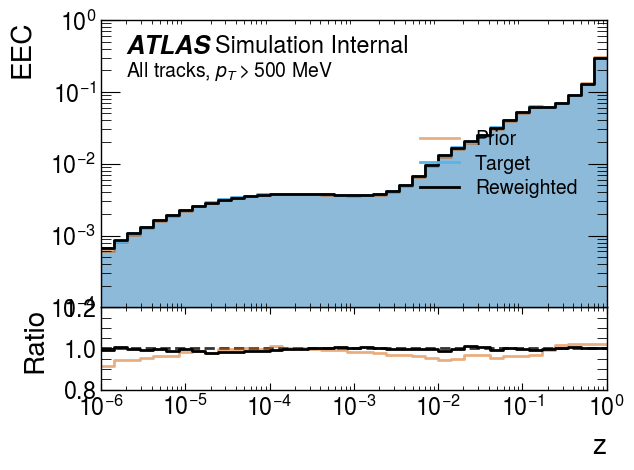

In [23]:
# Plot comparison to truth pseudodata (no uncertainties)
import visualize as vis
comp = vis.compare_to_target(
    measurement_hists,
    truth_pd_hists,
    log_xscale=True,
    linear_yscale=False,
    ylabel="EEC",
    xlabel="z",
    normalize=True,
    rlab="All tracks, $p_T > 500$ MeV",
)
comp.savefig("plot_storage/pd_eec_reweighting.pdf", dpi=300)
comp.show()

Chi-squared test: dof=39, χ²=44.88130, p-value=0.2389


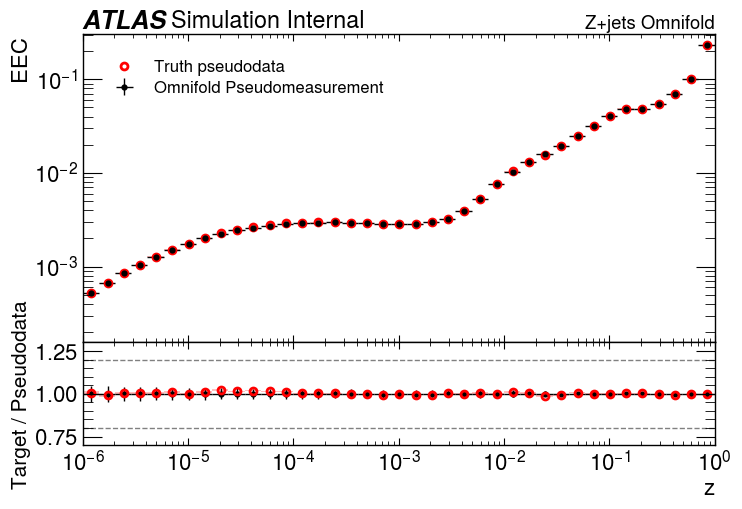

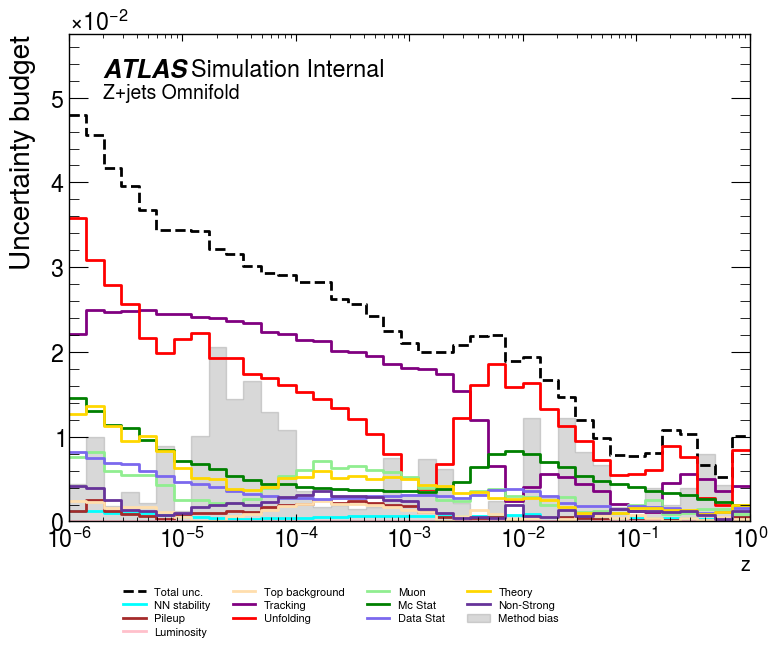

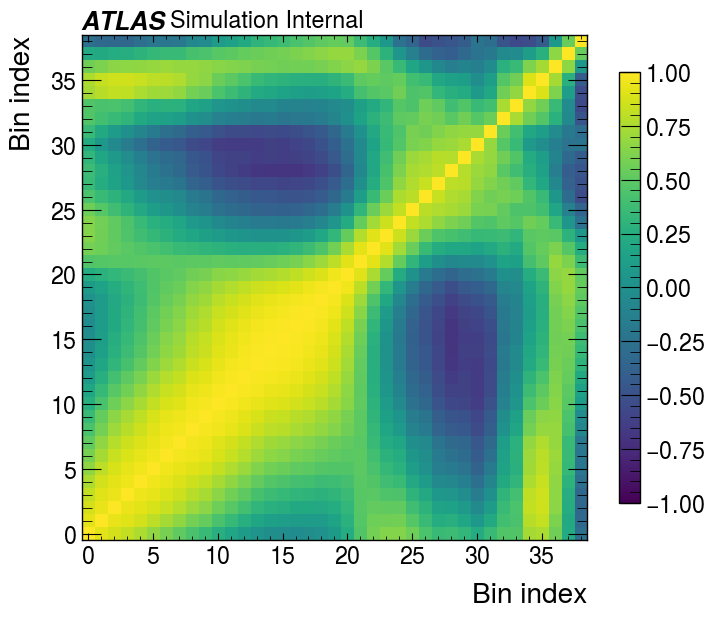

In [24]:
# Plot pseudo-measurement with full uncertainties
import visualize as vis

meas, budget, cov = vis.draw_plot(
    measurement_hists,
    bins,
    ylabel="EEC",
    xlabel="z",
    logyScale=True,
    logxScale=True,
    is_xSec=False,  # EEC is already a normalized, dimensionless quantity
    is_omni_data=False,  # pseudodata measurement, not real data
    ratio_ylim=[0.7, 1.3],
    draw_uncertainty_budget=True,
    draw_cov_matrix=True,
    results_list=[truth_pd_hists],
    formatting_dicts=[
        {
            "color": "red",
            "label": "Truth pseudodata",
            "marker": "o",
            "is_omni_data": False,
            "is_truth_pd": True,
        }
    ],
    pdf_name="plot_storage/pd_eec_xsec.pdf",
    do_chi2_test=True,
    is_profile=True,
    smooth_hv=True,
)
meas.show()
budget.show()
cov.show()